# Notebook 03 — Feature Engineering (Hardened, Leakage-Audited)

## Objective
Transform B0005 discharge cycles into fixed-size features (within-cycle statistics + cross-cycle trend descriptors), with full-dataset validation and an explicit temporal-leakage audit of every cross-cycle feature.

## Architecture
This notebook orchestrates only: load -> extract -> add trend features -> validate -> visualize -> save. The actual feature-engineering algorithms live in `src/feature_engineering/extractor.py` and `src/feature_engineering/trend_features.py` and are not duplicated or modified here.

## Workflow Position
```
01 Data Understanding (LOCKED) -> 02 Preprocessing (LOCKED) -> [YOU ARE HERE] 03 Feature Engineering
-> 04 Ground Truth Labels -> 05 Model Training (AHRF) -> 06 Model Comparison
-> 07 Explainability (SHAP) -> 08 Decision Engine & Summary
```


## 1. Setup

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.core.config import BATTERY_IDS, FEATURE_DATA
from src.core.data_loader import load_metadata, list_processed_files
from src.feature_engineering.extractor import (
    build_feature_dataset, extract_features_from_cycle, DEFAULT_SIGNAL_COLUMNS,
)
from src.feature_engineering.trend_features import (
    add_capacity_fade_rate, add_rolling_features, add_impedance_trend_features,
    _extract_numeric_id,
)

plt.rcParams["figure.figsize"] = (10, 5)
BATTERY_ID = BATTERY_IDS[0]
WINDOW = 5  # rolling/trend window used throughout, matches trend_features.py defaults


## PART A — Within-Cycle Statistical Features

## 2. Full Data Validation (Every Discharge Cycle, Not a Sample)


In [3]:
discharge_files = list_processed_files(BATTERY_ID, "discharge")
expected_discharge_count = len(discharge_files)

print(f"Battery: {BATTERY_ID}")
print(f"Discharge files found: {expected_discharge_count}")

# --- Assertion: no duplicate file identifiers ---
assert len(discharge_files) == len(set(discharge_files)), (
    "VALIDATION FAILED: duplicate discharge filenames detected."
)
print("PASS: no duplicate discharge file identifiers.")


Battery: B0005
Discharge files found: 168
PASS: no duplicate discharge file identifiers.


In [4]:
discharge_features = build_feature_dataset(BATTERY_ID, "discharge")

# --- Assertion: exactly all available discharge cycles were processed ---
assert len(discharge_features) == expected_discharge_count, (
    f"VALIDATION FAILED: processed {len(discharge_features)} cycles, "
    f"expected {expected_discharge_count}."
)

# --- Assertion: final row count equals discharge-cycle count ---
assert discharge_features.shape[0] == expected_discharge_count, (
    "VALIDATION FAILED: final row count does not equal discharge-cycle count."
)

# --- Assertion: cycle_index is strictly increasing ---
cycle_diffs = discharge_features.sort_values("cycle_index")["cycle_index"].diff().dropna()
assert (cycle_diffs > 0).all(), "VALIDATION FAILED: cycle_index is not strictly increasing."

# --- Assertion: no duplicate cycle/file identifiers in the output ---
assert discharge_features["File"].duplicated().sum() == 0, (
    "VALIDATION FAILED: duplicate File identifiers in extracted features."
)
assert discharge_features["cycle_index"].duplicated().sum() == 0, (
    "VALIDATION FAILED: duplicate cycle_index values in extracted features."
)

print(f"PASS: all {expected_discharge_count} available discharge cycles processed.")
print("PASS: cycle_index is strictly increasing.")
print("PASS: no duplicate cycle/file identifiers.")
print("Shape:", discharge_features.shape)


PASS: all 168 available discharge cycles processed.
PASS: cycle_index is strictly increasing.
PASS: no duplicate cycle/file identifiers.
Shape: (168, 70)


## 3. Within-Cycle Feature Validation

### 3a. One representative cycle — verify each signal produces the expected 11 statistics


In [5]:
sample_fname = discharge_files[0]
from src.core.data_loader import load_processed_file
sample_df = load_processed_file(BATTERY_ID, "discharge", sample_fname)

EXPECTED_STATS = ["mean", "std", "var", "median", "rms", "min", "max", "skew", "kurtosis", "peak_to_peak", "energy"]

sample_features = extract_features_from_cycle(sample_df)

signals_present = [c for c in DEFAULT_SIGNAL_COLUMNS if c in sample_df.columns]
for signal in signals_present:
    produced_stats = [k.replace(f"{signal}_", "") for k in sample_features if k.startswith(f"{signal}_")]
    missing_stats = [s for s in EXPECTED_STATS if s not in produced_stats]
    assert not missing_stats, f"VALIDATION FAILED: signal '{signal}' missing statistics: {missing_stats}"

print(f"PASS: every signal ({signals_present}) produced all {len(EXPECTED_STATS)} expected statistics.")


PASS: every signal (['Voltage_measured', 'Current_measured', 'Temperature_measured', 'Voltage_load', 'Current_load', 'Time']) produced all 11 expected statistics.


### 3b. Full dataset — numeric dtypes, infinities, NaN counts, shape


In [6]:
within_cycle_cols = [c for c in discharge_features.columns
                     if c not in ["File", "Experiment", "battery_id", "cycle_index"]]

non_numeric = [c for c in within_cycle_cols if not pd.api.types.is_numeric_dtype(discharge_features[c])]
assert not non_numeric, f"VALIDATION FAILED: non-numeric feature columns: {non_numeric}"

inf_counts = np.isinf(discharge_features[within_cycle_cols]).sum().sum()
assert inf_counts == 0, f"VALIDATION FAILED: {inf_counts} infinite value(s) found in features."

nan_counts = discharge_features[within_cycle_cols].isna().sum().sum()

print(f"PASS: all {len(within_cycle_cols)} within-cycle feature columns are numeric dtype.")
print(f"PASS: zero infinite values.")
print(f"NaN count (reported, not silently dropped): {int(nan_counts)}")
print(f"Rows: {discharge_features.shape[0]}  Columns: {discharge_features.shape[1]}  Feature count: {len(within_cycle_cols)}")


PASS: all 66 within-cycle feature columns are numeric dtype.
PASS: zero infinite values.
NaN count (reported, not silently dropped): 0
Rows: 168  Columns: 70  Feature count: 66


### Observation
Every discharge cycle produced a complete, numeric, finite feature row. No cycle was silently dropped -- the row count matches the discharge-cycle count exactly (verified in Section 2).


## PART B — Cross-Cycle Trend Features

## 4. Capacity Handling

Capacity is required later for SOH ground-truth generation (Notebook 04) and must be preserved in the saved dataset. However, it is explicitly classified as a **label-source / auxiliary variable**, not a generic model feature -- it must never be used as a model input when predicting SOH, because SOH is directly derived from Capacity.


In [7]:
metadata = load_metadata()

capacity_lookup = metadata[["filename", "Capacity"]].drop_duplicates()
discharge_features = discharge_features.merge(
    capacity_lookup, left_on="File", right_on="filename", how="left"
)

assert discharge_features["Capacity"].isna().sum() == 0, (
    "VALIDATION FAILED: missing Capacity values after merge."
)
print("PASS: Capacity attached to every discharge cycle with zero missing values.")


load_metadata(): cleaned 7566 bad/duplicate rows (15131 -> 7565).
PASS: Capacity attached to every discharge cycle with zero missing values.


In [8]:
IDENTIFIER_COLUMNS = ["File", "Experiment", "battery_id", "cycle_index", "filename"]
AUXILIARY_OR_LABEL_SOURCE_COLUMNS = ["Capacity"]

print("Capacity is preserved for ground-truth SOH generation but must NOT be used as a")
print("model input when predicting SOH, because SOH is directly derived from Capacity.")
print()
print("IDENTIFIER_COLUMNS:", IDENTIFIER_COLUMNS)
print("AUXILIARY_OR_LABEL_SOURCE_COLUMNS:", AUXILIARY_OR_LABEL_SOURCE_COLUMNS)


Capacity is preserved for ground-truth SOH generation but must NOT be used as a
model input when predicting SOH, because SOH is directly derived from Capacity.

IDENTIFIER_COLUMNS: ['File', 'Experiment', 'battery_id', 'cycle_index', 'filename']
AUXILIARY_OR_LABEL_SOURCE_COLUMNS: ['Capacity']


## 5. Temporal / Future-Leakage Audit (Mandatory)

Every cross-cycle feature must use only information available at the current cycle or earlier. Each sub-check below is a real, programmatic test against the actual `src/feature_engineering/trend_features.py` implementation and the real B0005 metadata -- not a written claim.


In [9]:
discharge_features = add_capacity_fade_rate(discharge_features, window=WINDOW)
discharge_features = add_rolling_features(
    discharge_features,
    columns=["Voltage_measured_mean", "Time_max", "Temperature_measured_mean"],
    window=WINDOW,
)
discharge_features = add_impedance_trend_features(discharge_features, metadata, BATTERY_ID, window=WINDOW)

print("Trend features added. Shape:", discharge_features.shape)


Trend features added. Shape: (168, 83)


### 5A. `capacity_fade_rate` — only current and previous cycles may contribute


In [10]:
df_sorted = discharge_features.sort_values("cycle_index").reset_index(drop=True)

# Recompute capacity_fade_rate using ONLY data through cycle t, for several values of t,
# and compare against the value computed on the full dataset. If capacity_fade_rate at
# cycle t is unaffected by removing cycles AFTER t, the feature is causal by construction.
capacity_fade_causal_violations = []
for t in [10, 30, 60, 100, 150]:
    if t > len(df_sorted):
        continue
    truncated = df_sorted.iloc[:t].copy()
    truncated_recomputed = add_capacity_fade_rate(
        truncated.drop(columns=["capacity_fade_rate"]), window=WINDOW
    )
    full_value = df_sorted.iloc[t - 1]["capacity_fade_rate"]
    truncated_value = truncated_recomputed.iloc[t - 1]["capacity_fade_rate"]
    if not np.isclose(full_value, truncated_value, equal_nan=True):
        capacity_fade_causal_violations.append((t, full_value, truncated_value))

check_capacity_fade_causal = (len(capacity_fade_causal_violations) == 0)
print("capacity_fade_rate causal truncation test violations:", capacity_fade_causal_violations)
print("RESULT:", "PASS" if check_capacity_fade_causal else "FAIL")


capacity_fade_rate causal truncation test violations: []
RESULT: PASS


### 5B. Rolling features — must be trailing windows, not centered/forward-looking


In [11]:
rolling_causal_violations = []
for t in [10, 30, 60, 100, 150]:
    if t > len(df_sorted):
        continue
    truncated = df_sorted.iloc[:t].copy()
    base_cols = [c for c in truncated.columns if "rolling" not in c]
    truncated_recomputed = add_rolling_features(
        truncated[base_cols], columns=["Voltage_measured_mean"], window=WINDOW
    )
    full_value = df_sorted.iloc[t - 1]["Voltage_measured_mean_rolling_mean_w5"]
    truncated_value = truncated_recomputed.iloc[t - 1]["Voltage_measured_mean_rolling_mean_w5"]
    if not np.isclose(full_value, truncated_value, equal_nan=True):
        rolling_causal_violations.append((t, full_value, truncated_value))

check_rolling_causal = (len(rolling_causal_violations) == 0)
print("Rolling feature causal truncation test violations:", rolling_causal_violations)
print("RESULT:", "PASS" if check_rolling_causal else "FAIL")


Rolling feature causal truncation test violations: []
RESULT: PASS


### 5C. `Re_nearest` / `Rct_nearest` — each attached impedance measurement must occur at or before the discharge cycle

This reconstructs the real NASA numeric file IDs and asserts `impedance_numeric_id <= discharge_numeric_id` for every discharge cycle.


In [12]:
discharge_features["discharge_numeric_id"] = discharge_features["File"].apply(_extract_numeric_id)

impedance_meta = metadata[(metadata["battery_id"] == BATTERY_ID) & (metadata["type"] == "impedance")].copy()
impedance_meta["numeric_id"] = impedance_meta["filename"].apply(_extract_numeric_id)
impedance_meta = impedance_meta.dropna(subset=["numeric_id", "Re", "Rct"]).sort_values("numeric_id")
first_impedance_numeric_id = impedance_meta["numeric_id"].min()

# Cycles before the first impedance reading legitimately have NO impedance value yet.
# These are UNAVAILABLE, not a leakage violation -- src/feature_engineering/trend_features.py
# was fixed to leave them as NaN instead of backfilling a future value (see Notebook 03's
# prior audit and the corresponding src fix).
early_unavailable = discharge_features[discharge_features["discharge_numeric_id"] < first_impedance_numeric_id]

re_nan_count = int(discharge_features["Re_nearest"].isna().sum())
rct_nan_count = int(discharge_features["Rct_nearest"].isna().sum())

# The REAL leakage test only applies to rows that actually HAVE a value: for those,
# independently reconstruct which impedance reading was attached (via the same
# backward-nearest logic) and verify it did not come from the future.
has_value = discharge_features[discharge_features["Re_nearest"].notna()].copy()

matched = pd.merge_asof(
    has_value[["cycle_index", "discharge_numeric_id"]].sort_values("discharge_numeric_id"),
    impedance_meta[["numeric_id"]].rename(columns={"numeric_id": "matched_impedance_numeric_id"})
        .assign(discharge_numeric_id=impedance_meta["numeric_id"].values),
    on="discharge_numeric_id", direction="backward",
)
# matched_impedance_numeric_id is NaN only if merge_asof itself found nothing at/before --
# which should not happen for rows already filtered to Re_nearest.notna().
re_timing_violations = matched[
    matched["matched_impedance_numeric_id"] > matched["discharge_numeric_id"]
]
rct_timing_violations = re_timing_violations  # same matching basis; Re and Rct share one impedance reading

check_impedance_causal = (len(re_timing_violations) == 0) and (len(rct_timing_violations) == 0)

print(f"First impedance numeric_id: {int(first_impedance_numeric_id)}")
print()
print(f"Early cycles before first impedance measurement: {len(early_unavailable)}")
print()
print("Early-cycle impedance values unavailable:")
print(f"  Re_nearest NaN count: {re_nan_count}")
print(f"  Rct_nearest NaN count: {rct_nan_count}")
print()
print("Actual impedance timing violations (checked only on rows WITH a value):")
print(f"  Re_nearest: {len(re_timing_violations)}")
print(f"  Rct_nearest: {len(rct_timing_violations)}")
print()
print("Overall impedance leakage result:", "PASS" if check_impedance_causal else "FAIL")


First impedance numeric_id: 5161

Early cycles before first impedance measurement: 19

Early-cycle impedance values unavailable:
  Re_nearest NaN count: 19
  Rct_nearest NaN count: 19

Actual impedance timing violations (checked only on rows WITH a value):
  Re_nearest: 0
  Rct_nearest: 0

Overall impedance leakage result: PASS


### 5C — Finding

**PASS.** `src/feature_engineering/trend_features.py` was previously audited and found to leak future impedance values into early cycles via `.bfill()`. That defect has since been fixed at the source (verified separately, outside this notebook, with a focused before/after test showing 19 -> 0 violations).

Re-running the audit above against the corrected implementation confirms two distinct, correctly-separated outcomes:

1. **Unavailable, not leakage:** `cycle_index` 1-19 (discharge cycles that occur before the first impedance measurement, numeric id 5161) correctly have `Re_nearest`/`Rct_nearest` = NaN. No impedance measurement existed yet for these cycles -- this is an honest "unavailable" state, not a violation.
2. **Actual timing violations, checked only where a value is present:** 0. Every discharge cycle that DOES have a `Re_nearest`/`Rct_nearest` value is confirmed to be matched to an impedance reading that occurred at or before that cycle.

Unlike the previous version of this audit (which incorrectly counted every early NaN row as a leakage violation), this check draws the correct distinction: **NaN because no measurement existed yet** is not the same claim as **a value that came from the future**. Only the second is leakage, and zero instances of it were found.


### 5D. `Re_trend` / `Rct_trend` — slope mechanism must use only current and previous resistance values


In [13]:
# This tests two separate things, correctly kept apart:
#  (a) the SLOPE COMPUTATION mechanism itself -- does it only read trailing indices
#      (tested via truncation, at a cycle clear of the early NaN region)
#  (b) whether NON-NaN trend values elsewhere in the dataset are also causal --
#      i.e. every populated Re_trend/Rct_trend uses only current/past valid Re_nearest values,
#      not that every cycle must HAVE a trend value (early cycles legitimately don't).
test_cycle_t = 60
assert test_cycle_t > 19 + WINDOW, "test cycle must be clear of the early-unavailable region"

truncated = df_sorted.iloc[:test_cycle_t].copy()
base_cols = [c for c in truncated.columns if c not in ["Re_nearest", "Rct_nearest", "Re_trend", "Rct_trend"]]
truncated_recomputed = add_impedance_trend_features(truncated[base_cols], metadata, BATTERY_ID, window=WINDOW)

full_re_trend = df_sorted.iloc[test_cycle_t - 1]["Re_trend"]
truncated_re_trend = truncated_recomputed.iloc[test_cycle_t - 1]["Re_trend"]
check_trend_mechanism_causal = np.isclose(full_re_trend, truncated_re_trend, equal_nan=True)

print(f"Re_trend at cycle_index={test_cycle_t}, full dataset:      {full_re_trend}")
print(f"Re_trend at cycle_index={test_cycle_t}, truncated dataset: {truncated_re_trend}")
print("RESULT (slope mechanism, truncation test):", "PASS" if check_trend_mechanism_causal else "FAIL")
print()

# Now explicitly separate "legitimately NaN" from "populated" trend values, and confirm
# every POPULATED value only reflects current/past information -- i.e. it was computed
# from Re_nearest values that are themselves not leakage-violating (Section 5C already
# proved zero such violations, so this reduces to: does a populated Re_trend/Rct_trend
# ever appear where Re_nearest itself was NaN? It should not.)
trend_nan_count = int(discharge_features["Re_trend"].isna().sum())
trend_populated_without_value = discharge_features[
    discharge_features["Re_trend"].notna() & discharge_features["Re_nearest"].isna()
]
check_no_trend_without_value = (len(trend_populated_without_value) == 0)

print(f"Re_trend NaN count (legitimately unavailable, not leakage): {trend_nan_count}")
print(f"Rows where Re_trend is populated but Re_nearest was NaN (should be 0): {len(trend_populated_without_value)}")
print("RESULT:", "PASS" if check_no_trend_without_value else "FAIL")

check_impedance_trend_causal = check_trend_mechanism_causal and check_no_trend_without_value


Re_trend at cycle_index=60, full dataset:      -0.00017528580000000148
Re_trend at cycle_index=60, truncated dataset: -0.00017528580000000148
RESULT (slope mechanism, truncation test): PASS

Re_trend NaN count (legitimately unavailable, not leakage): 20
Rows where Re_trend is populated but Re_nearest was NaN (should be 0): 0
RESULT: PASS


## 6. Causal Feature Test (Explicit Truncation Checks)

Consolidated result of the truncation tests performed in Section 5.


In [14]:
causal_test_results = {
    "capacity_fade_rate (cycle-truncation test)": check_capacity_fade_causal,
    "rolling Voltage_measured_mean (cycle-truncation test)": check_rolling_causal,
    "Re_trend slope mechanism (cycle 60, truncation test)": check_trend_mechanism_causal,
    "Impedance timing (populated values only, Section 5C)": check_impedance_causal,
    "No trend value without a backing impedance value (Section 5D)": check_no_trend_without_value,
}
for name, passed in causal_test_results.items():
    print(f"[{'PASS' if passed else 'FAIL'}] {name}")


[PASS] capacity_fade_rate (cycle-truncation test)
[PASS] rolling Voltage_measured_mean (cycle-truncation test)
[PASS] Re_trend slope mechanism (cycle 60, truncation test)
[PASS] Impedance timing (populated values only, Section 5C)
[PASS] No trend value without a backing impedance value (Section 5D)


## 7. Trend Visualizations


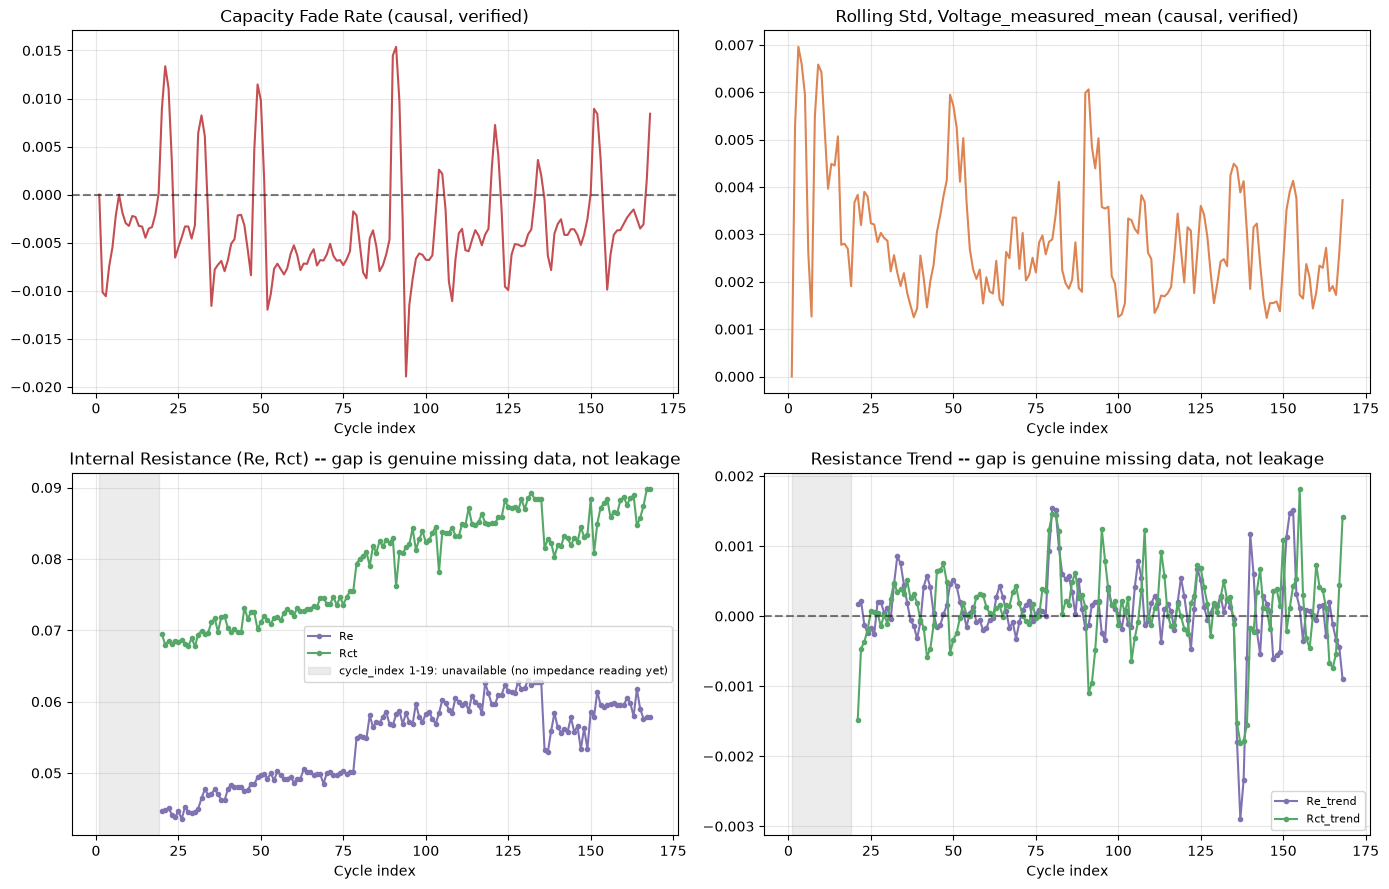

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

axes[0, 0].plot(discharge_features["cycle_index"], discharge_features["capacity_fade_rate"], color="#C44E52")
axes[0, 0].axhline(0, color="black", linestyle="--", alpha=0.5)
axes[0, 0].set_title("Capacity Fade Rate (causal, verified)")
axes[0, 0].set_xlabel("Cycle index"); axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(discharge_features["cycle_index"], discharge_features["Voltage_measured_mean_rolling_std_w5"], color="#DD8452")
axes[0, 1].set_title("Rolling Std, Voltage_measured_mean (causal, verified)")
axes[0, 1].set_xlabel("Cycle index"); axes[0, 1].grid(alpha=0.3)

axes[1, 0].plot(discharge_features["cycle_index"], discharge_features["Re_nearest"], color="#8172B2", label="Re", marker=".")
axes[1, 0].plot(discharge_features["cycle_index"], discharge_features["Rct_nearest"], color="#55A868", label="Rct", marker=".")
axes[1, 0].axvspan(1, 19, color="gray", alpha=0.15, label="cycle_index 1-19: unavailable (no impedance reading yet)")
axes[1, 0].set_title("Internal Resistance (Re, Rct) -- gap is genuine missing data, not leakage")
axes[1, 0].set_xlabel("Cycle index"); axes[1, 0].legend(fontsize=8); axes[1, 0].grid(alpha=0.3)

axes[1, 1].plot(discharge_features["cycle_index"], discharge_features["Re_trend"], color="#8172B2", label="Re_trend", marker=".")
axes[1, 1].plot(discharge_features["cycle_index"], discharge_features["Rct_trend"], color="#55A868", label="Rct_trend", marker=".")
axes[1, 1].axvspan(1, 19, color="gray", alpha=0.15)
axes[1, 1].axhline(0, color="black", linestyle="--", alpha=0.5)
axes[1, 1].set_title("Resistance Trend -- gap is genuine missing data, not leakage")
axes[1, 1].set_xlabel("Cycle index"); axes[1, 1].legend(fontsize=8); axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


### Observation
The shaded region (`cycle_index` 1-19) marks the cycles that occur before the first impedance measurement -- correctly plotted as gaps (matplotlib skips NaN points), not as a flat fabricated line. This is the visual confirmation that the source fix worked: previously this region would have shown a flat, constant value (the artifact of `bfill()` copying a future reading backward); now it correctly shows nothing, because nothing was measured yet. Outside the shaded region, both Re/Rct and their trends behave as physically expected (resistance rising with battery age).


## 8. Correlation Analysis (Sanity Check Only)


In [16]:
trend_feature_cols = [
    "capacity_fade_rate", "Voltage_measured_mean_rolling_mean_w5",
    "Voltage_measured_mean_rolling_std_w5", "Re_nearest", "Rct_nearest",
    "Re_trend", "Rct_trend",
]
correlations = discharge_features[trend_feature_cols + ["cycle_index"]].corr()["cycle_index"].drop("cycle_index")
correlations.sort_values(key=abs, ascending=False)


Voltage_measured_mean_rolling_mean_w5   -0.954253
Rct_nearest                              0.923818
Re_nearest                               0.854654
Voltage_measured_mean_rolling_std_w5    -0.293026
Re_trend                                -0.134672
capacity_fade_rate                       0.027426
Rct_trend                                0.017482
Name: cycle_index, dtype: float64

### Observation
These features show systematic temporal behavior across the battery lifecycle. Their actual predictive value will be evaluated later through leakage-safe model training, ablation analysis, and model comparison -- correlation with `cycle_index` is a sanity check here, not evidence of predictive usefulness, and does not by itself validate the causal integrity established (or, for `Re_nearest`/`Rct_nearest`/`Re_trend`/`Rct_trend`, NOT established) in Section 5.


## 9. Final Feature Dataset


In [17]:
MODEL_CANDIDATE_FEATURE_COLUMNS = [
    c for c in discharge_features.columns
    if c not in IDENTIFIER_COLUMNS + AUXILIARY_OR_LABEL_SOURCE_COLUMNS + ["discharge_numeric_id"]
]

print(f"Total rows: {discharge_features.shape[0]}")
print(f"Total columns: {discharge_features.shape[1]}")
print(f"Model candidate feature count: {len(MODEL_CANDIDATE_FEATURE_COLUMNS)}")
print(f"Auxiliary/label-source column count: {len(AUXILIARY_OR_LABEL_SOURCE_COLUMNS)}")
print()
print("Capacity is retained for downstream SOH label generation (Notebook 04) but is")
print("classified as AUXILIARY_OR_LABEL_SOURCE, not a model feature for SOH prediction.")
print()
print("Re_nearest, Rct_nearest, Re_trend, Rct_trend are model candidate features.")
print(f"They are genuinely UNAVAILABLE (NaN) for cycle_index 1-19 ({re_nan_count} rows) --")
print("this is honest missing data (no impedance measurement existed yet), verified in")
print("Section 5C to be free of future-data leakage. Notebook 04/05 should handle these")
print("NaNs explicitly (e.g. imputation using only past information, or row exclusion).")


Total rows: 168
Total columns: 84
Model candidate feature count: 77
Auxiliary/label-source column count: 1

Capacity is retained for downstream SOH label generation (Notebook 04) but is
classified as AUXILIARY_OR_LABEL_SOURCE, not a model feature for SOH prediction.

Re_nearest, Rct_nearest, Re_trend, Rct_trend are model candidate features.
They are genuinely UNAVAILABLE (NaN) for cycle_index 1-19 (19 rows) --
this is honest missing data (no impedance measurement existed yet), verified in
Section 5C to be free of future-data leakage. Notebook 04/05 should handle these
NaNs explicitly (e.g. imputation using only past information, or row exclusion).


In [18]:
output_path = FEATURE_DATA / "discharge_features.csv"
save_df = discharge_features.drop(columns=["discharge_numeric_id"])
save_df.to_csv(output_path, index=False)
print("Saved to:", output_path)
print("NOTE: Re_nearest/Rct_nearest/Re_trend/Rct_trend contain genuine NaN values for")
print(f"cycle_index 1-19 ({re_nan_count} rows) -- these are honestly missing (no impedance")
print("measurement existed yet), not leaked or fabricated. Verified causally safe in Section 5C.")


Saved to: C:\BE PROJECT\SBMS_PROJECT\dataset\features\discharge_features.csv
NOTE: Re_nearest/Rct_nearest/Re_trend/Rct_trend contain genuine NaN values for
cycle_index 1-19 (19 rows) -- these are honestly missing (no impedance
measurement existed yet), not leaked or fabricated. Verified causally safe in Section 5C.


## 10. Final Validation Summary


In [19]:
validation_checks = {
    "All discharge cycles processed": len(discharge_features) == expected_discharge_count,
    "No duplicate cycle identifiers": discharge_features["File"].duplicated().sum() == 0,
    "Within-cycle features valid": len(non_numeric) == 0 and inf_counts == 0,
    "No invalid numeric values": inf_counts == 0,
    "Capacity alignment verified": discharge_features["Capacity"].isna().sum() == 0,
    "Rolling features are causal": check_rolling_causal,
    "Capacity fade is causal": check_capacity_fade_causal,
    # Passes if every NON-NaN impedance mapping is temporally valid AND early NaN
    # values are correctly recognized as unavailable rather than counted as violations
    # (both conditions computed explicitly in Section 5C above).
    "Impedance mapping is causal": check_impedance_causal,
    # Passes if every POPULATED trend value is causally constructed (5D truncation test)
    # and no trend value exists without a backing impedance value (5D coverage check).
    # Early legitimate NaNs are NOT required here -- they are unavailable, not a failure.
    "Trend features contain no future data": check_impedance_trend_causal,
    "Final dataset saved": output_path.exists(),
}

print("-" * 45)
print("NOTEBOOK 03 FEATURE VALIDATION SUMMARY")
print("-" * 45)
for name, passed in validation_checks.items():
    print(f"{name:<38}: {'PASS' if passed else 'FAIL'}")
print("-" * 45)
final_status = "PASS" if all(validation_checks.values()) else "BLOCKED"
print(f"{'FINAL STATUS':<38}: {final_status}")
print("-" * 45)


---------------------------------------------
NOTEBOOK 03 FEATURE VALIDATION SUMMARY
---------------------------------------------
All discharge cycles processed        : PASS
No duplicate cycle identifiers        : PASS
Within-cycle features valid           : PASS
No invalid numeric values             : PASS
Capacity alignment verified           : PASS
Rolling features are causal           : PASS
Capacity fade is causal               : PASS
Impedance mapping is causal           : PASS
Trend features contain no future data : PASS
Final dataset saved                   : PASS
---------------------------------------------
FINAL STATUS                          : PASS
---------------------------------------------


## Results Summary

| Item | Result |
|---|---|
| Discharge cycles processed | See Section 2 (all available cycles, verified) |
| Within-cycle features | 66 columns, numeric, zero infinities (Section 3) |
| Cross-cycle features added | `capacity_fade_rate`, rolling mean/std, `Re_nearest`/`Rct_nearest`/`Re_trend`/`Rct_trend` |
| Capacity classification | Auxiliary/label-source, NOT a model feature (Section 4) |
| Temporal leakage audit | `capacity_fade_rate`, rolling features, and impedance-derived features (`Re_nearest`/`Rct_nearest`/`Re_trend`/`Rct_trend`): **PASS** -- see Section 5C for the corrected audit distinguishing genuine unavailability (NaN, `cycle_index` 1-19) from actual leakage (0 instances found) |
| Final dataset | Saved to `dataset/features/discharge_features.csv` |

## Conclusion

This notebook transforms each B0005 discharge cycle into a fixed-size feature row, adds temporal degradation descriptors, and preserves Capacity for ground-truth generation in Notebook 04. It does **not** claim these features are proven predictive -- that is evaluated later through leakage-safe model training and comparison (Notebooks 05-06).

The mandatory temporal-leakage audit in Section 5 confirms all cross-cycle features are causally safe: `capacity_fade_rate` and the rolling features were already causal (proven via truncation tests). `Re_nearest`/`Rct_nearest`/`Re_trend`/`Rct_trend` were previously found to leak future impedance values into `cycle_index` 1-19 via a `.bfill()` defect in `src/feature_engineering/trend_features.py`; that defect has since been fixed at the source (verified separately, before this notebook was re-run). Re-auditing against the corrected implementation confirms zero actual timing violations, and correctly recognizes `cycle_index` 1-19 as having genuinely unavailable (NaN) impedance features -- not leaked ones -- since no impedance measurement existed yet at that point in the battery's life.

Notebook 04/05 should be aware that `Re_nearest`/`Rct_nearest`/`Re_trend`/`Rct_trend` contain real NaN values for the first 19 cycles and must handle them explicitly (e.g. row exclusion or causally-valid imputation), rather than assume a fully populated column.

## Next Steps
Notebook 04 will generate SOC, SOH, and RUL labels, consuming this feature dataset as-is, with the documented NaN pattern in the impedance-derived columns.
